In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm
from matplotlib.patches import Circle
from matplotlib.colors import LogNorm, SymLogNorm

fname = "SL_all_p05/modes.h5"

def lm_of_n(n):
    l = int(np.floor(np.sqrt(n)))
    m = n - l*l - l
    return l, m

# ------------------------------------------------------------
# Parámetros de la reconstrucción polar directa
# ------------------------------------------------------------

Rs = 1.0

# Radio interior a graficar.
# Usa Rs=1 para ocultar el interior del horizonte.
# Usa r_data.min() después de cargar si quieres mostrar hasta la excisión numérica.
r_inner_plot = Rs

# Radio exterior mostrado
Lbox = 5000.0

# Resolución angular
Nphi = 320

# Si la figura pesa mucho, usa r_stride=2, 3, 4...
# r_stride=1 usa directamente todos los puntos radiales disponibles.
r_stride = 2

# ------------------------------------------------------------
# Cargar datos
# ------------------------------------------------------------

modes = []

with h5py.File(fname, "r") as f:
    groups = sorted(
        [g for g in f.keys() if g.startswith("mode_")],
        key=lambda s: int(s.split("_")[1])
    )

    g0 = groups[0]

    if "r" in f:
        r_data = f["r"][:].astype(np.float64)
    else:
        r_data = f[g0]["vr"][:, 0].astype(np.float64)

    t_data = f[g0]["t"][:]

    r_outer_plot = min(Lbox, r_data.max())

    idx_r = np.where((r_data >= r_inner_plot) & (r_data <= r_outer_plot))[0]
    idx_r = idx_r[::r_stride]

    rp = r_data[idx_r]

    phip = np.linspace(-np.pi, np.pi, Nphi, endpoint=True, dtype=np.float64)

    RR, PP = np.meshgrid(rp, phip, indexing="ij")
    XX = RR * np.cos(PP)
    YY = RR * np.sin(PP)

    for g in groups:
        n = int(g.split("_")[1])
        l, m = lm_of_n(n)

        # En theta = pi/2, Y_lm = 0 si l+m es impar
        if (l + m) % 2 != 0:
            continue

        # Parte angular completa en el plano xy:
        # theta = pi/2, phi = phip
        Y0 = sph_harm(m, l, 0.0, np.pi/2)
        Yphi = Y0 * np.exp(1j * m * phip)

        # phi tiene forma {2, Nr, Nt}
        # Guardamos únicamente el rango radial que vamos a graficar
        phi_all = f[g]["phi"][:, idx_r, :].astype(np.float32)

        modes.append((l, m, phi_all, Yphi.astype(np.complex64)))

print("Modos usados:", [(l, m) for l, m, _, _ in modes])
print("Nt =", len(t_data))
print("Nr original =", len(r_data))
print("Nr usado para graficar =", len(rp))
print("r_inner_plot =", r_inner_plot)
print("r_outer_plot =", r_outer_plot)
print("Nphi =", Nphi)

/tmp/ipykernel_5810/1174646689.py:80: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y0 = sph_harm(m, l, 0.0, np.pi/2)
/tmp/ipykernel_5810/1174646689.py:85: RuntimeWarning: overflow encountered in cast
  phi_all = f[g]["phi"][:, idx_r, :].astype(np.float32)


Modos usados: [(0, 0), (1, -1), (1, 1), (2, -2), (2, 0), (2, 2), (3, -3), (3, -1), (3, 1), (3, 3), (4, -4), (4, -2), (4, 0), (4, 2), (4, 4), (5, -5), (5, -3), (5, -1), (5, 1), (5, 3), (5, 5), (6, -6), (6, -4), (6, -2), (6, 0), (6, 2), (6, 4), (6, 6), (7, -7), (7, -5), (7, -3), (7, -1), (7, 1), (7, 3), (7, 5), (7, 7), (8, -8), (8, -6), (8, -4), (8, -2), (8, 0), (8, 2), (8, 4), (8, 6), (8, 8), (9, -9), (9, -7), (9, -5), (9, -3), (9, -1), (9, 1), (9, 3), (9, 5), (9, 7), (9, 9), (10, -10), (10, -8), (10, -6), (10, -4), (10, -2), (10, 0), (10, 2), (10, 4), (10, 6), (10, 8), (10, 10), (11, -11), (11, -9), (11, -7), (11, -5), (11, -3), (11, -1), (11, 1), (11, 3), (11, 5), (11, 7), (11, 9), (11, 11), (12, -12), (12, -10), (12, -8), (12, -6), (12, -4), (12, -2), (12, 0), (12, 2), (12, 4), (12, 6), (12, 8), (12, 10), (12, 12), (13, -13), (13, -11), (13, -9), (13, -7), (13, -5), (13, -3), (13, -1), (13, 1), (13, 3), (13, 5), (13, 7), (13, 9), (13, 11), (13, 13), (14, -14), (14, -12), (14, -10), (

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.patches import Circle

try:
    from scipy.special import sph_harm_y

    def _Ylm_direct(ell, m, theta, phi):
        # scipy nuevo:
        # sph_harm_y(ell, m, theta, phi)
        return sph_harm_y(ell, m, theta, phi)

except ImportError:
    from scipy.special import sph_harm

    def _Ylm_direct(ell, m, theta, phi):
        # scipy clásico:
        # sph_harm(m, ell, phi, theta)
        return sph_harm(m, ell, phi, theta)


_modes_xy_direct_cache = None
_modes_xy_direct_signature = None


def _prepare_modes_xy_direct():
    """
    Precalcula Y_lm(pi/2, phip) directamente en el plano xy.

    Usa todos los modos que ya estén en la variable global modes.
    Ignora cualquier Yphi previamente guardado en modes.
    No impone simetrías.
    No usa reconstrucción sobre esfera completa.
    No recorta una malla cartesiana.
    """

    global _modes_xy_direct_cache
    global _modes_xy_direct_signature

    signature = (
        id(modes),
        len(modes),
        len(phip),
        float(phip[0]),
        float(phip[-1])
    )

    if _modes_xy_direct_cache is not None:
        if _modes_xy_direct_signature == signature:
            return _modes_xy_direct_cache

    theta_xy = np.full_like(phip, 0.5*np.pi, dtype=np.float64)

    modes_xy = []

    for item in modes:
        ell = int(item[0])
        m = int(item[1])
        phi_all = item[2]

        Yphi = _Ylm_direct(ell, m, theta_xy, phip).astype(np.complex128)

        modes_xy.append(
            (
                ell,
                m,
                phi_all,
                Yphi
            )
        )

    _modes_xy_direct_cache = modes_xy
    _modes_xy_direct_signature = signature

    return modes_xy


def reconstruct_phi_xy_polar_direct(it):
    """
    Reconstruye phi(t,x,y) usando directamente la malla radial rp
    y los armónicos evaluados en el plano xy.

    Implementa:

        phi(t,r,varphi)|_xy =
            sum_{ell,m} phi_lm(t,r) Y_lm(pi/2,varphi)

    No usa simetrías en m.
    No reconstruye en malla angular completa.
    No recorta una reconstrucción previa.
    No usa el Yphi guardado previamente en modes.

    Devuelve:
        field con shape (len(rp), len(phip))
    """

    modes_xy = _prepare_modes_xy_direct()

    field = np.zeros((len(rp), len(phip)), dtype=np.complex128)

    for ell, m, phi_all, Yphi in modes_xy:
        phi_lm_r = phi_all[0, :, it] + 1j*phi_all[1, :, it]

        field += phi_lm_r[:, None].astype(np.complex128) * Yphi[None, :]

    return field


def plot_phi_xy(
    it,
    part="abs",
    log_abs=False,
    sym_log=False,
    cmap_name="viridis",
    percentile_vmin=1.0,
    percentile_vmax=99.8,
    linthresh=1e-6,
    draw_outer_circle=True,
    draw_inner_circle=True
):
    """
    Grafica la reconstrucción polar directa en el plano xy.

    Parámetros
    ----------
    it : int
        Índice temporal.

    part : str
        "abs", "real" o "imag".

    log_abs : bool
        Si part="abs", usa escala logarítmica.

    sym_log : bool
        Si part="real" o part="imag", usa escala simétrica logarítmica.

    cmap_name : str
        Colormap.

    percentile_vmin, percentile_vmax : float
        Percentiles para fijar límites de color de forma robusta.

    linthresh : float
        Umbral lineal para SymLogNorm.
    """

    field = reconstruct_phi_xy_polar_direct(it)

    if part == "abs":
        Q = np.abs(field)
        label = r"$|\phi|$"

    elif part == "real":
        Q = field.real
        label = r"$\mathrm{Re}(\phi)$"

    elif part == "imag":
        Q = field.imag
        label = r"$\mathrm{Im}(\phi)$"

    else:
        raise ValueError("part debe ser 'abs', 'real' o 'imag'")

    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad("white")

    norm = None

    if part == "abs":

        if log_abs:
            positive = Q[np.isfinite(Q) & (Q > 0)]

            if positive.size == 0:
                raise ValueError("No hay valores positivos para usar LogNorm.")

            vmin = np.percentile(positive, percentile_vmin)
            vmax = np.percentile(positive, percentile_vmax)

            Q = np.where(Q >= vmin, Q, np.nan)
            norm = LogNorm(vmin=vmin, vmax=vmax)

        else:
            finite = Q[np.isfinite(Q)]

            if finite.size == 0:
                raise ValueError("No hay valores finitos para graficar.")

            vmin = np.percentile(finite, percentile_vmin)
            vmax = np.percentile(finite, percentile_vmax)

    else:
        finite = Q[np.isfinite(Q)]

        if finite.size == 0:
            raise ValueError("No hay valores finitos para graficar.")

        vmax = np.percentile(np.abs(finite), percentile_vmax)
        vmin = -vmax

        if sym_log:
            norm = SymLogNorm(
                linthresh=linthresh,
                vmin=vmin,
                vmax=vmax
            )

    Qplot = np.ma.masked_invalid(Q)

    fig, ax = plt.subplots(figsize=(6.4, 5.6))

    if norm is None:
        im = ax.pcolormesh(
            XX,
            YY,
            Qplot,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )
    else:
        im = ax.pcolormesh(
            XX,
            YY,
            Qplot,
            shading="auto",
            cmap=cmap,
            norm=norm
        )

    ax.set_aspect("equal")
    ax.set_xlim(-r_outer_plot, r_outer_plot)
    ax.set_ylim(-r_outer_plot, r_outer_plot)

    if draw_outer_circle:
        ax.add_patch(
            Circle(
                (0.0, 0.0),
                r_outer_plot,
                fill=False,
                color="k",
                linewidth=1.2,
                zorder=5
            )
        )

    if draw_inner_circle:
        ax.add_patch(
            Circle(
                (0.0, 0.0),
                r_inner_plot,
                facecolor="black",
                edgecolor="black",
                linewidth=1.0,
                zorder=6
            )
        )

    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(fr"{label} en plano $xy$, $t={t_data[it]:.3f}$")

    plt.colorbar(im, ax=ax, label=label)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_5810/2440680597.py:216: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


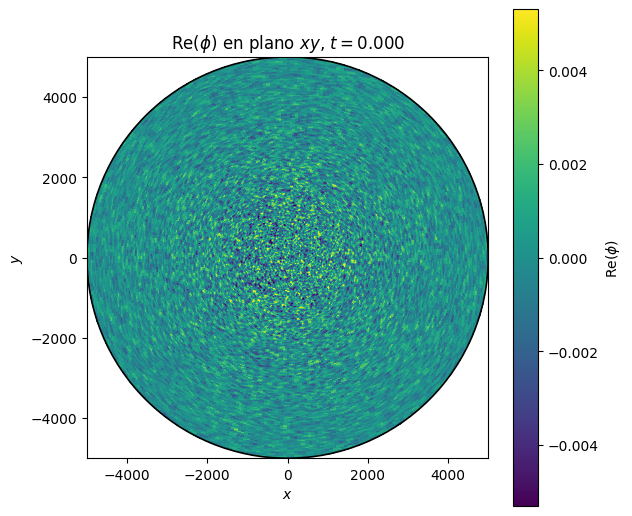

In [9]:
plot_phi_xy(it=0, part="real", log_abs=False)

In [15]:
# Cell — Movie polar direct: escala fija, sin huecos de fondo y sin última instantánea

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.patches import Circle
from IPython.display import Video, Image, display
import shutil
import os


# ============================================================
# Parámetros de la película
# ============================================================

part = "abs"          # "abs", "real", "imag"
log_abs = True        # solo para part="abs"
sym_log = False       # solo para part="real" o "imag"

cmap_name = "viridis"

# Estos percentiles ya no se usan para la escala global fija,
# se dejan por si después quieres volver a escala local.
percentile_vmin = 1.0
percentile_vmax = 99.8
linthresh = 1e-6

fps = 12
dpi = 140

FRAME_STRIDE = 1

# Escala fija durante toda la película.
USE_FRAME_LOCAL_SCALE = False

# La barra de color usará el 90% de los extremos globales.
EXTREMA_FRACTION = 0.90

draw_outer_circle = True
draw_inner_circle = True

output_basename = "phi_xy_p01"


# ============================================================
# Lista de snapshots
# ============================================================

# Excluye la última instantánea porque aparece vacía
frames = np.arange(0, len(t_data) - 1, FRAME_STRIDE, dtype=int)

if len(frames) == 0:
    raise ValueError("No hay frames disponibles después de excluir la última instantánea.")

print(f"Generando película con {len(frames)} snapshots.")
print(f"Último snapshot incluido: it = {frames[-1]}, t = {t_data[frames[-1]]:.6f}")


# ============================================================
# Funciones auxiliares
# ============================================================

def quantity_from_field(field, part):
    if part == "abs":
        return np.abs(field), r"$|\phi|$"
    elif part == "real":
        return field.real, r"$\mathrm{Re}(\phi)$"
    elif part == "imag":
        return field.imag, r"$\mathrm{Im}(\phi)$"
    else:
        raise ValueError("part debe ser 'abs', 'real' o 'imag'")


def get_limits(Q, part):
    """
    Calcula vmin/vmax de forma robusta.
    Solo se usa si USE_FRAME_LOCAL_SCALE = True.
    """
    if part == "abs":
        if log_abs:
            vals = Q[np.isfinite(Q) & (Q > 0)]

            if vals.size == 0:
                raise ValueError("No hay valores positivos para usar LogNorm.")

            vmin = np.percentile(vals, percentile_vmin)
            vmax = np.percentile(vals, percentile_vmax)

            if vmin <= 0:
                vmin = vals.min()

            if vmax <= vmin:
                vmax = vals.max()

            if vmax <= vmin:
                vmax = vmin * 1.01

        else:
            vals = Q[np.isfinite(Q)]

            if vals.size == 0:
                raise ValueError("No hay valores finitos para graficar.")

            vmin = np.percentile(vals, percentile_vmin)
            vmax = np.percentile(vals, percentile_vmax)

            if vmax <= vmin:
                vmax = vmin + 1e-30

    else:
        vals = Q[np.isfinite(Q)]

        if vals.size == 0:
            raise ValueError("No hay valores finitos para graficar.")

        vmax = np.percentile(np.abs(vals), percentile_vmax)

        if vmax <= 0:
            vmax = np.max(np.abs(vals))

        if vmax <= 0:
            vmax = 1e-30

        vmin = -vmax

    return vmin, vmax


def make_norm(part, vmin, vmax):
    if part == "abs" and log_abs:
        return LogNorm(vmin=vmin, vmax=vmax)

    if part in ("real", "imag") and sym_log:
        return SymLogNorm(
            linthresh=linthresh,
            vmin=vmin,
            vmax=vmax
        )

    return None


def prepare_quantity_for_plot(Q, part, vmin, vmax):
    """
    Evita huecos blancos:
    - En escala logarítmica, valores <= 0 o muy pequeños se ponen en vmin.
    - Los valores fuera del rango fijo se saturan a vmin/vmax.
    - Solo se enmascaran valores realmente no finitos.
    """
    Q = np.asarray(Q).copy()

    finite = np.isfinite(Q)

    if part == "abs" and log_abs:
        # Los valores no positivos no pueden entrar a LogNorm.
        # En vez de enmascararlos, los saturamos al color mínimo.
        Q[finite & (Q <= 0)] = vmin

        # Escala fija: todo queda saturado dentro de [vmin, vmax].
        Q[finite] = np.clip(Q[finite], vmin, vmax)

        return np.ma.masked_invalid(Q)

    else:
        Q[finite] = np.clip(Q[finite], vmin, vmax)
        return np.ma.masked_invalid(Q)


# ============================================================
# Escala global fija
# ============================================================

global_vmin = None
global_vmax = None

values_for_norm = []

for it in frames:
    field = reconstruct_phi_xy_polar_direct(it)
    Q, label = quantity_from_field(field, part)

    if part == "abs" and log_abs:
        vals = Q[np.isfinite(Q) & (Q > 0)]
    else:
        vals = Q[np.isfinite(Q)]

    if vals.size > 0:
        values_for_norm.append(vals.ravel())

if len(values_for_norm) == 0:
    raise ValueError("No hay valores para estimar la normalización global.")

values_for_norm = np.concatenate(values_for_norm)

if part == "abs":
    if log_abs:
        positive = values_for_norm[values_for_norm > 0]

        if positive.size == 0:
            raise ValueError("No hay valores positivos para usar LogNorm.")

        global_min = np.min(positive)
        global_max = np.max(positive)

        global_vmin = EXTREMA_FRACTION * global_min
        global_vmax = EXTREMA_FRACTION * global_max

        if global_vmin <= 0:
            global_vmin = global_min

        if global_vmax <= global_vmin:
            global_vmax = global_max

        if global_vmax <= global_vmin:
            global_vmax = global_vmin * 1.01

    else:
        global_min = np.min(values_for_norm)
        global_max = np.max(values_for_norm)

        global_vmin = EXTREMA_FRACTION * global_min
        global_vmax = EXTREMA_FRACTION * global_max

        if global_vmax <= global_vmin:
            global_vmax = global_vmin + 1e-30

else:
    global_min = np.min(values_for_norm)
    global_max = np.max(values_for_norm)

    global_vmin = EXTREMA_FRACTION * global_min
    global_vmax = EXTREMA_FRACTION * global_max

    if global_vmax <= global_vmin:
        amp = np.max(np.abs(values_for_norm))

        if amp <= 0:
            amp = 1e-30

        global_vmin = -EXTREMA_FRACTION * amp
        global_vmax =  EXTREMA_FRACTION * amp


print("Escala global fija:")
print(f"global_vmin = {global_vmin:.6e}")
print(f"global_vmax = {global_vmax:.6e}")


# ============================================================
# Crear figura inicial
# ============================================================

cmap = plt.get_cmap(cmap_name).copy()
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(6.4, 5.6))

it0 = frames[0]
field0 = reconstruct_phi_xy_polar_direct(it0)
Q0, label = quantity_from_field(field0, part)

if USE_FRAME_LOCAL_SCALE:
    vmin, vmax = get_limits(Q0, part)
else:
    vmin, vmax = global_vmin, global_vmax

norm = make_norm(part, vmin, vmax)
Q0_plot = prepare_quantity_for_plot(Q0, part, vmin, vmax)

if norm is None:
    im = ax.pcolormesh(
        XX,
        YY,
        Q0_plot,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
else:
    im = ax.pcolormesh(
        XX,
        YY,
        Q0_plot,
        shading="auto",
        cmap=cmap,
        norm=norm
    )

ax.set_aspect("equal")
ax.set_xlim(-r_outer_plot, r_outer_plot)
ax.set_ylim(-r_outer_plot, r_outer_plot)

if draw_outer_circle:
    ax.add_patch(
        Circle(
            (0.0, 0.0),
            r_outer_plot,
            fill=False,
            color="k",
            linewidth=1.2,
            zorder=5
        )
    )

if draw_inner_circle:
    ax.add_patch(
        Circle(
            (0.0, 0.0),
            r_inner_plot,
            facecolor="black",
            edgecolor="black",
            linewidth=1.0,
            zorder=6
        )
    )

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")

title = ax.set_title(fr"{label} en plano $xy$, $t={t_data[it0]:.3f}$")

cbar = plt.colorbar(im, ax=ax, label=label)

plt.tight_layout()


# ============================================================
# Función de actualización
# ============================================================

def update(frame_number):
    it = frames[frame_number]

    field = reconstruct_phi_xy_polar_direct(it)
    Q, _ = quantity_from_field(field, part)

    if USE_FRAME_LOCAL_SCALE:
        vmin, vmax = get_limits(Q, part)
        norm = make_norm(part, vmin, vmax)
        Qplot = prepare_quantity_for_plot(Q, part, vmin, vmax)

        im.set_norm(norm)

        if norm is None:
            im.set_clim(vmin, vmax)

        cbar.update_normal(im)

    else:
        vmin, vmax = global_vmin, global_vmax
        Qplot = prepare_quantity_for_plot(Q, part, vmin, vmax)

    im.set_array(Qplot.ravel())

    title.set_text(fr"{label} en plano $xy$, $t={t_data[it]:.3f}$")

    return im, title


# ============================================================
# Crear animación
# ============================================================

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000 / fps,
    blit=False
)

plt.close(fig)


# ============================================================
# Guardar y desplegar
# ============================================================

if shutil.which("ffmpeg") is not None:
    out_file = output_basename + ".mp4"

    writer = animation.FFMpegWriter(
        fps=fps,
        bitrate=2400
    )

    anim.save(out_file, writer=writer, dpi=dpi)

    print(f"Película guardada en: {os.path.abspath(out_file)}")
    display(Video(out_file, embed=True))

else:
    out_file = output_basename + ".gif"

    writer = animation.PillowWriter(fps=fps)
    anim.save(out_file, writer=writer, dpi=dpi)

    print(f"GIF guardado en: {os.path.abspath(out_file)}")
    display(Image(filename=out_file))

Generando película con 101 snapshots.
Último snapshot incluido: it = 100, t = 40000.000000
Escala global fija:
global_vmin = 8.170094e-10
global_vmax = 8.518161e-04


/tmp/ipykernel_14089/2283605776.py:283: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


Película guardada en: /home/flavio/Codes/KG-Y/phi_xy_p01.mp4


In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


def n_of_lm(ell, m):
    """
    Inversa de:
        ell = floor(sqrt(n))
        m = n - ell^2 - ell

    Entonces:
        n = ell^2 + ell + m
    """
    return ell*ell + ell + m


def find_group_for_lm(f, ell_target, m_target):
    """
    Busca el grupo mode_XXXXX correspondiente a un ell,m.
    """
    n_target = n_of_lm(ell_target, m_target)

    # Primero intenta con formato estándar
    candidates = [
        f"mode_{n_target:05d}",
        f"mode_{n_target:04d}",
        f"mode_{n_target}"
    ]

    for gname in candidates:
        if gname in f:
            return gname

    # Si no lo encuentra, busca recorriendo todos los grupos
    for gname in f.keys():
        if not gname.startswith("mode_"):
            continue

        n = int(gname.split("_")[1])
        ell, m = lm_of_n(n)

        if ell == ell_target and m == m_target:
            return gname

    raise KeyError(f"No encontré el modo ell={ell_target}, m={m_target}, n={n_target}")


def read_complex_mode_dataset(g, var):
    """
    Lee un dataset complejo guardado como:
        var shape = (2, Nr, Nt)
    o complejo nativo.
    """
    if var not in g:
        raise KeyError(f"No existe '{var}' en {g.name}. Datasets disponibles: {list(g.keys())}")

    A = g[var][:]

    if np.iscomplexobj(A):
        return A

    # Caso esperado en tu archivo: (2, Nr, Nt)
    if A.ndim == 3 and A.shape[0] == 2:
        return A[0, :, :] + 1j*A[1, :, :]

    # Caso alternativo: (Nr, Nt, 2)
    if A.ndim == 3 and A.shape[-1] == 2:
        return A[:, :, 0] + 1j*A[:, :, 1]

    raise ValueError(f"Formato inesperado para {g.name}/{var}: shape={A.shape}")


def plot_lm_1d(
    fname,
    ell,
    m,
    i=1,
    vars_to_plot=("phi", "psi", "pi"),
    rlim=(0.45, 5.0),
    logy=True,
    normalize=False,
    abs_only=True,
):
    """
    Grafica perfiles radiales 1D de un modo específico (ell,m).

    Parámetros:
        fname        : archivo HDF5
        ell, m       : modo deseado
        i            : índice temporal
        vars_to_plot : variables a graficar, por ejemplo ("phi", "psi", "pi")
        rlim         : límites radiales
        logy         : escala logarítmica para |campo|
        normalize    : normaliza cada perfil por su máximo
        abs_only     : si True grafica |campo|; si False grafica Re, Im y |campo|
    """

    with h5py.File(fname, "r") as f:

        gname = find_group_for_lm(f, ell, m)
        g = f[gname]

        if "r" in f:
            r = f["r"][:]
        elif "vr" in g:
            r = g["vr"][:, 0]
        else:
            raise KeyError("No encontré r en el archivo ni vr en el grupo.")

        if "t" in g:
            t = g["t"][:]
        elif "t" in f:
            t = f["t"][:]
        else:
            t = None

        if t is not None:
            time_label = fr"$t={t[i]:.6g}$"
        else:
            time_label = fr"$i={i}$"

        print(f"Graficando grupo: {gname}")
        print(f"Modo: ell={ell}, m={m}, n={n_of_lm(ell,m)}")
        print(f"Tiempo: {time_label}")

        for var in vars_to_plot:

            A = read_complex_mode_dataset(g, var)

            if A.ndim != 2:
                raise ValueError(f"Esperaba {var} con shape (Nr,Nt), llegó {A.shape}")

            if i >= A.shape[1]:
                raise IndexError(f"i={i} fuera de rango para {var}. Nt={A.shape[1]}")

            prof = A[:, i]
            amp = np.abs(prof)

            max_amp = np.nanmax(amp)
            idx_max = np.nanargmax(amp)
            r_max = r[idx_max]

            print(f"{var}: max |{var}| = {max_amp:.6e} en r = {r_max:.6e}")

            if abs_only:
                y = amp.copy()

                if normalize and max_amp > 0:
                    y = y / max_amp

                if logy:
                    y = np.maximum(y, 1e-300)

                plt.figure(figsize=(8, 4.5))
                plt.plot(r, y, lw=1.4)

                plt.axvline(1.0, color="k", ls="--", lw=1.0, label=r"$R_s$")
                plt.axvline(r[0], color="gray", ls=":", lw=1.0, label=r"$r_{\min}$")

                plt.xlim(*rlim)
                plt.xlabel(r"$r/R_s$")

                if normalize:
                    plt.ylabel(fr"$|{var}_{{\ell m}}|/\max |{var}_{{\ell m}}|$")
                else:
                    plt.ylabel(fr"$|{var}_{{\ell m}}|$")

                plt.title(fr"$|{var}_{{\ell m}}(r)|$, $\ell={ell}$, $m={m}$, {time_label}")

                if logy:
                    plt.yscale("log")

                plt.grid(alpha=0.25)
                plt.legend()
                plt.tight_layout()
                plt.show()

            else:
                plt.figure(figsize=(8, 4.5))

                plt.plot(r, np.real(prof), lw=1.2, label=fr"$\mathrm{{Re}}({var})$")
                plt.plot(r, np.imag(prof), lw=1.2, label=fr"$\mathrm{{Im}}({var})$")
                plt.plot(r, amp, lw=1.4, color="k", label=fr"$|{var}|$")

                plt.axvline(1.0, color="k", ls="--", lw=1.0, alpha=0.7)
                plt.axvline(r[0], color="gray", ls=":", lw=1.0)

                plt.xlim(*rlim)
                plt.xlabel(r"$r/R_s$")
                plt.ylabel(fr"${var}_{{\ell m}}$")
                plt.title(fr"${var}_{{\ell m}}(r)$, $\ell={ell}$, $m={m}$, {time_label}")

                plt.grid(alpha=0.25)
                plt.legend()
                plt.tight_layout()
                plt.show()

In [14]:
plot_lm_1d(
    fname,
    ell=0,
    m=0,
    i=80,
    vars_to_plot=("phi", "pi"),
    rlim=(0.5, 5000.0),
    logy=False,
    normalize=False,
    abs_only=False
)



NameError: name 'plot_lm_1d' is not defined

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

H5FILE = "SL_all_p01/modes.h5"


def n_to_ellm(n):
    ell = int(np.sqrt(n))
    r = n - ell * ell
    m = int(r) - ell
    return ell, m


def ellm_to_n(ell, m):
    if abs(m) > ell:
        raise ValueError(f"Modo inválido: ell={ell}, m={m}. Debe cumplirse |m| <= ell.")
    return ell*ell + ell + m


def mode_group_name(n):
    return f"mode_{n:05d}"


def ellm_group_name(ell, m):
    return mode_group_name(ellm_to_n(ell, m))

In [2]:
def read_r(h5file=H5FILE):
    """
    Intenta leer la coordenada radial desde el archivo.
    Si no existe, devuelve None.
    """
    with h5py.File(h5file, "r") as f:
        candidates = ["r", "rp", "grid/r", "mesh/r"]

        for name in candidates:
            if name in f:
                return f[name][:]

    return None


def get_available_modes(h5file=H5FILE):
    rows = []

    with h5py.File(h5file, "r") as f:
        for key in f.keys():
            if not key.startswith("mode_"):
                continue

            n = int(key.split("_")[1])
            ell, m = n_to_ellm(n)

            rows.append({
                "group": key,
                "n": n,
                "ell": ell,
                "m": m,
            })

    df = pd.DataFrame(rows).sort_values(["ell", "m"]).reset_index(drop=True)
    return df


modes_df = get_available_modes(H5FILE)

display(modes_df.head())
display(modes_df.tail())

print(f"Modos disponibles: {len(modes_df)}")
print(f"ell mínimo = {modes_df['ell'].min()}")
print(f"ell máximo = {modes_df['ell'].max()}")

,group,n,ell,m
0,mode_00000,0,0,0
1,mode_00001,1,1,-1
2,mode_00002,2,1,0
3,mode_00003,3,1,1
4,mode_00004,4,2,-2


,group,n,ell,m
6556,mode_06556,6556,80,76
6557,mode_06557,6557,80,77
6558,mode_06558,6558,80,78
6559,mode_06559,6559,80,79
6560,mode_06560,6560,80,80


Modos disponibles: 6561
ell mínimo = 0
ell máximo = 80


In [3]:
def read_phi_mode(ell, m, h5file=H5FILE):
    """
    Lee phi para un modo específico (ell,m).

    Devuelve:
        r      : arreglo radial, o índice radial si no existe r en el archivo
        t      : tiempos guardados para phi
        phi    : arreglo complejo con shape (Nr, Nt)
    """

    group = ellm_group_name(ell, m)

    with h5py.File(h5file, "r") as f:
        if group not in f:
            raise KeyError(f"No existe el grupo {group}")

        phi_raw = f[group]["phi"][:]   # shape (2, Nr, Nt)
        t = f[group]["t"][:]

    phi = phi_raw[0, :, :] + 1j*phi_raw[1, :, :]

    r = read_r(h5file)

    if r is None:
        r = np.arange(phi.shape[0])

    return r, t, phi

In [4]:
def nearest_index(array, value):
    return int(np.argmin(np.abs(array - value)))


def plot_phi_radial_profiles(
    modes,
    times,
    h5file=H5FILE,
    part="abs",
    rmax_plot=None,
    logy=False
):
    """
    Grafica perfiles radiales de phi para varios modos y tiempos.

    modes:
        lista [(ell,m), ...]

    times:
        lista de tiempos físicos/adimensionales que existan cerca de t

    part:
        "abs"  -> |phi|
        "real" -> Re(phi)
        "imag" -> Im(phi)
    """

    nrows = len(times)
    fig, axes = plt.subplots(nrows, 1, figsize=(8, 4*nrows), sharex=True)

    if nrows == 1:
        axes = [axes]

    for ax, time_value in zip(axes, times):

        for ell, m in modes:
            r, t, phi = read_phi_mode(ell, m, h5file=h5file)
            it = nearest_index(t, time_value)

            if part == "abs":
                y = np.abs(phi[:, it])
                ylabel = r"$|\phi_{\ell m}|$"
            elif part == "real":
                y = np.real(phi[:, it])
                ylabel = r"$\mathrm{Re}(\phi_{\ell m})$"
            elif part == "imag":
                y = np.imag(phi[:, it])
                ylabel = r"$\mathrm{Im}(\phi_{\ell m})$"
            else:
                raise ValueError("part debe ser 'abs', 'real' o 'imag'.")

            if rmax_plot is not None:
                mask = r <= rmax_plot
                r_plot = r[mask]
                y_plot = y[mask]
            else:
                r_plot = r
                y_plot = y

            ax.plot(
                r_plot,
                y_plot,
                label=fr"$\ell={ell},\,m={m}$"
            )

        ax.set_title(fr"$t = {t[it]:.3f}$")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend()

        if logy and part == "abs":
            ax.set_yscale("log")

    axes[-1].set_xlabel(r"$r$")
    plt.tight_layout()
    plt.show()

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, Video, display
import shutil
import os

H5FILE = "SL_all_p01/modes.h5"


def ellm_to_n(ell, m):
    if abs(m) > ell:
        raise ValueError(f"Modo inválido: ell={ell}, m={m}. Debe cumplirse |m| <= ell.")
    return ell*ell + ell + m


def mode_group_name_from_ellm(ell, m):
    n = ellm_to_n(ell, m)
    return f"mode_{n:05d}"


def read_r_from_file(h5file=H5FILE, Nr=None):
    """
    Intenta leer la malla radial.
    Si no existe en el archivo, usa índice radial.
    """
    with h5py.File(h5file, "r") as f:
        candidates = ["r", "rp", "grid/r", "mesh/r"]

        for name in candidates:
            if name in f:
                return f[name][:], r"$r$"

    if Nr is None:
        raise ValueError("No se encontró r y no se proporcionó Nr.")

    return np.arange(Nr), "índice radial"


def read_phi_mode_for_movie(ell, m, h5file=H5FILE):
    """
    Lee solo phi para un modo específico.

    phi_raw tiene shape:
        (2, Nr, Nt)

    Devuelve:
        r
        t
        phi complejo con shape (Nr, Nt)
    """
    group = mode_group_name_from_ellm(ell, m)

    with h5py.File(h5file, "r") as f:
        if group not in f:
            raise KeyError(f"No existe el grupo {group}")

        phi_raw = f[group]["phi"][:]   # (2, Nr, Nt)
        t = f[group]["t"][:]           # (Nt,)

    phi = phi_raw[0, :, :] + 1j*phi_raw[1, :, :]

    r, r_label = read_r_from_file(h5file, Nr=phi.shape[0])

    return r, r_label, t, phi

In [6]:
def make_phi_radial_profile_movie(
    ell,
    m,
    h5file=H5FILE,
    part="abs",
    rmin_plot=None,
    rmax_plot=None,
    logy=False,
    fps=12,
    dpi=150,
    drop_last=True,
    output=None
):
    """
    Crea una película del perfil radial de phi_{ell,m}(r,t).

    Parámetros:
        part:
            "abs"  -> |phi|
            "real" -> Re(phi)
            "imag" -> Im(phi)

        logy:
            True solo recomendado para part="abs".

        drop_last:
            True excluye la última instantánea, útil si aparece vacía.

        output:
            nombre del archivo de salida.
            Si output=None, se genera automáticamente.
    """

    r, r_label, t, phi = read_phi_mode_for_movie(ell, m, h5file=h5file)

    if drop_last:
        t = t[:-1]
        phi = phi[:, :-1]

    if part == "abs":
        Y = np.abs(phi)
        ylabel = r"$|\phi_{\ell m}|$"
        part_name = "abs"
    elif part == "real":
        Y = np.real(phi)
        ylabel = r"$\mathrm{Re}(\phi_{\ell m})$"
        part_name = "real"
    elif part == "imag":
        Y = np.imag(phi)
        ylabel = r"$\mathrm{Im}(\phi_{\ell m})$"
        part_name = "imag"
    else:
        raise ValueError("part debe ser 'abs', 'real' o 'imag'.")

    mask = np.ones_like(r, dtype=bool)

    if rmin_plot is not None:
        mask &= (r >= rmin_plot)

    if rmax_plot is not None:
        mask &= (r <= rmax_plot)

    r_plot = r[mask]
    Y_plot = Y[mask, :]

    if logy:
        if part != "abs":
            raise ValueError("logy=True solo tiene sentido para part='abs'.")
        positive = Y_plot[Y_plot > 0]
        ymin = positive.min() if positive.size > 0 else 1e-30
        ymax = Y_plot.max()
        ymin = max(ymin, ymax * 1e-8)
    else:
        ymin = np.nanpercentile(Y_plot, 0.5)
        ymax = np.nanpercentile(Y_plot, 99.8)

        if part == "real" or part == "imag":
            amp = max(abs(ymin), abs(ymax))
            ymin, ymax = -amp, amp
        else:
            ymin = 0.0

    if output is None:
        output = f"phi_l{ell:03d}_m{m:+03d}_{part_name}.mp4"
        output = output.replace("+", "p").replace("-", "m")

    fig, ax = plt.subplots(figsize=(8, 5))

    line, = ax.plot([], [], lw=2)

    ax.set_xlim(r_plot.min(), r_plot.max())
    ax.set_ylim(ymin, ymax)

    if logy:
        ax.set_yscale("log")

    ax.set_xlabel(r_label)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

    title = ax.set_title("")

    def init():
        line.set_data([], [])
        title.set_text("")
        return line, title

    def update(it):
        line.set_data(r_plot, Y_plot[:, it])
        title.set_text(
            rf"$\ell={ell},\,m={m}$, "
            rf"$t={t[it]:.3f}$"
        )
        return line, title

    anim = FuncAnimation(
        fig,
        update,
        frames=len(t),
        init_func=init,
        blit=True,
        interval=1000/fps
    )

    plt.close(fig)

    if output.endswith(".mp4"):
        if shutil.which("ffmpeg") is not None:
            anim.save(output, writer="ffmpeg", fps=fps, dpi=dpi)
            display(Video(output, embed=True))
        else:
            gif_output = output.replace(".mp4", ".gif")
            anim.save(gif_output, writer=PillowWriter(fps=fps), dpi=dpi)
            display(HTML(f'<img src="{gif_output}">'))
            output = gif_output

    elif output.endswith(".gif"):
        anim.save(output, writer=PillowWriter(fps=fps), dpi=dpi)
        display(HTML(f'<img src="{output}">'))

    else:
        raise ValueError("El archivo de salida debe terminar en .mp4 o .gif")

    print(f"Película guardada en: {output}")
    return output

In [7]:
make_phi_radial_profile_movie(
    ell=0,
    m=0,
    part="abs",
    rmin_plot=0,
    rmax_plot=5000,
    logy=False,
    fps=12,
    drop_last=True
)

Película guardada en: phi_l000_mp00_abs.mp4


'phi_l000_mp00_abs.mp4'